### 4-3. 수치 미분
###### 신경망 학습에서 주요한 방법이 loss function의 기울기 값을 기준으로 나아갈 방향을 정하는 것이다. 그렇기 때문에 수치 미분에 대해 간략히 보고 가겠다.

-----

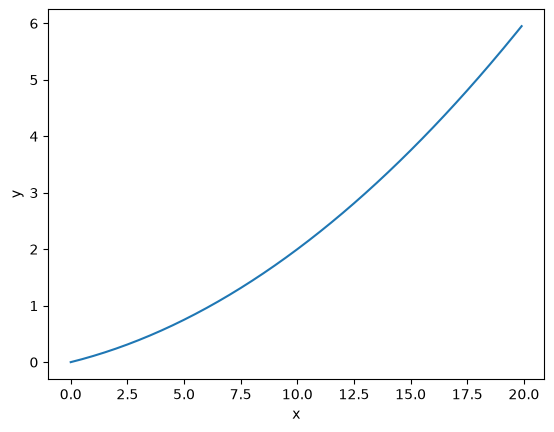

0.1999999999990898
0.2999999999986347


In [13]:
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f,x): # 중앙 차분을 이용해서 미분 def를 만듦
    h = 1e-4 
    return (f(x+h) - f(x-h)) / (2 * h)

def function_1(x):
    return 0.01*x**2 + 0.1*x

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x, y)
plt.show()

print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))


In [15]:
# 편미분

import numpy as np

def function_2(x):
    return x[0]**2 + x[1]**2


def numerical_diff(f,x): # 중앙 차분을 이용해서 미분 def를 만듦
    h = 1e-4 
    return (f(x+h) - f(x-h)) / (2 * h)

# x_0 = 3, x_1 = 4

def function_tmp1(x0):
    return x0 * x0 + 4**2

print(numerical_diff(function_tmp1, 3))




6.00000000000378


### 4-4. 기울기

###### 각 변수에 대한 편미분값
----

In [ ]:
# 기울기를 구하는 코드


def function_2(x):
    return x[0]**2 + x[1]**2


def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) # x와 형상이 같고 원소가 모두 0인 배열을 만든다.


    for idx in range(x.size):
        tmp_val = x[idx]
        
        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val -h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val

    return grad

print(numerical_gradient(function_2, np.array([3.0, 4.0])))
print(numerical_gradient(function_2, np.array([0.0, 2.0])))
print(numerical_gradient(function_2, np.array([3.0, 0.0])))



[6. 8.]
[0. 4.]
[6. 0.]


#### 경사법(경사 하강법)
###### loss function이 최솟값이 될 때의 매개변수 값을 구하기 위해서 기울기를 잘 이용해 함수의 최솟값을 찾으려는 것

- *기울기가 가리키는 곳이 무조건 최솟값이 있는 것이 아니라, 값을 줄여주는 방향을 제공해주는 거다.

----

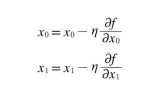

- n기호는 학습률을 나타낸다.
- 이 식을 계속 반복하며 값을 update한다.

In [ ]:
import numpy as np

def function_2(x):
    return x[0]**2 + x[1]**2


def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) # x와 형상이 같고 원소가 모두 0인 배열을 만든다.


    for idx in range(x.size):
        tmp_val = x[idx]
        
        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val -h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val

    return grad


def gradient_descent(f, init_x, lr = 0.01, step_num = 100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
        
    return x


init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x = init_x, lr = 0.1, step_num = 100)) # 하이퍼파라미터 조절 중요!!


[-6.11110793e-10  8.14814391e-10]


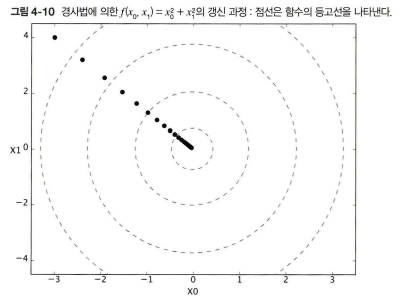


In [ ]:
# 신경망에서의 기울기
# Loss function을 가중치 W에 대해서 나타내야 한다.


import sys, os
sys.path.insert(
    0,
    os.path.abspath("../deeplearning_from_scratch")
)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:

    def __init__(self):
        self.W = np.random.randn(2,3)

    def predict(self, x):
        return np.dot(x,self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss


def f(W):
    return net.loss(x,t)


net = simpleNet()
print(net.W)
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)
t = np.array([0, 0, 1])
l = net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)


[[-0.32119282  0.31086911 -1.46028811]
 [-0.33688999  0.84193094  0.00738115]]
[-0.49591668  0.94425931 -0.86952983]
[[ 0.10152831  0.42859553 -0.53012384]
 [ 0.15229246  0.6428933  -0.79518576]]
